# *Hidden Gem* Detector

**Objective:** Identify listings that are statistically underpriced relative to 
comparable properties using a price prediction model, not simply cheap properties, 
but ones that are underpriced relative to what their features suggest they should be worth.

**Modelling Decision:**  Two target variables were tested:
  1. Model A — predicts log(Price) directly, with Area as a feature
  2. Model B — predicts log(Price_per_m²), final price derived by multiplying   
  predicted Price_per_m² × actual Area
                                                                                
  Model A was selected as the winner. LightGBM on Model A consistently
  outperformed all Model B variants across all versions (v1–v4). Predicting
  total price directly, with Area as an explicit feature, gave the model more
  flexibility to capture non-linear size-price relationships that the Price/m²
  normalisation obscures.

Each will be tested with both **LightGBM** and **XGBoost**, evaluated using 
cross-validated RMSE and R². The best performing combination will be used 
to generate the Hidden Gem scores.

## Step 1: Import packages

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

## Step 2: Load the dataset

In [2]:
df = pd.read_csv('/Users/tomdevilliers/Documents/Thomas/Woolworths/Inca Tribe House Prices.csv')

#print(df.shape)
#print(df.head)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27322 entries, 0 to 27321
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Type            27322 non-null  object 
 1   Price           27322 non-null  int64  
 2   Bedrooms        27119 non-null  float64
 3   Bathrooms       27151 non-null  float64
 4   Area            26851 non-null  float64
 5   Furnished       27322 non-null  object 
 6   Level           27322 non-null  object 
 7   Compound        27322 non-null  object 
 8   Payment_Option  27322 non-null  object 
 9   Delivery_Date   27322 non-null  object 
 10  Delivery_Term   27322 non-null  object 
 11  City            27322 non-null  object 
dtypes: float64(3), int64(1), object(8)
memory usage: 2.5+ MB


### Notes

The dataset has 27,322 rows and 12 columns. 

**Datatypes look reasonable**
- `Price`,`Bedrooms`, `Bathrooms`, `Area` are quanititative fields: Price could possibly be modelled as a function of these
- All remaining columns categorical, Encoding will likely be needed here 

**Genuine nulls exist in:**
- `Bedrooms` — 203 missing
- `Bathrooms` — 171 missing  
- `Area` — 471 missing

**However, the null counts are misleading:**
- Pandas reports 27,322 non-null entries for most columns — suggesting no missing data. But this is because missing values have been encoded as the string "Unknown" rather than true NaN values.
- pandas doesnt detect these as missing 


**Before any analysis or modelling, we need to replace 
"Unknown" string variants with NaN so pandas treats them correctly. 
We also need to audit how widespread the "Unknown" masking is across 
each column.**

## Step 3: Determine True amount of Missing data

In [3]:
# Replace 'Unknown' variants with NaN 
df.replace(to_replace=r'^Unknown.*$', value=np.nan, regex=True, inplace=True)
df['Delivery_Term'] = df['Delivery_Term'].str.strip()
df.replace('Unknown ', np.nan, inplace=True)

# Missingness summary
missing = pd.DataFrame({
    'Missing Count': df.isna().sum(),
    'Missing %': (df.isna().mean() * 100).round(1)
}).sort_values('Missing %', ascending=False)

print(missing.to_string())

                Missing Count  Missing %
Compound                11032       40.4
Level                   10400       38.1
Delivery_Date           10072       36.9
Furnished                8491       31.1
Delivery_Term            4670       17.1
Payment_Option           3012       11.0
Area                      471        1.7
Bedrooms                  203        0.7
Bathrooms                 171        0.6
Type                        0        0.0
Price                       0        0.0
City                        0        0.0


After replacing `"Unknown"` string variants with `NaN`, the true missing values become visible:

* `Compound`, `Level`, `Delivery_Date`, and `Furnished` carry the highest missing data at 30–40%, these fields are still potentially useful but will need careful handling before modelling.
* `Delivery_Term` and `Payment_Option` 17% and 11% respectively 
* `Area`, `Bedrooms`, and `Bathrooms` are largely complete, likely will be the numeric price drivers and form a reliable foundation.
* `Type`, `Price`, and `City` are fully populated, city will most likely be the biggest driver (but I will wait to confirm this)

*takeaway*: pandas reported near-zero nulls on the raw load because missing values were masked as strings. This is a data quality issue that would silently corrupt any model trained on the raw data.

## Step 4: Market Overview

In [4]:
cat_cols = ['Type', 'City', 'Furnished', 'Payment_Option', 'Delivery_Term', 'Delivery_Date']

for col in cat_cols:
    print(f"\n=== {col} ({df[col].nunique()} unique values) ===")
    print(df[col].value_counts().head(10))
    print(f"Missing: {df[col].isna().sum()} ({df[col].isna().mean()*100:.1f}%)")


=== Type (10 unique values) ===
Type
Apartment            8506
Chalet               6593
Stand Alone Villa    4629
Town House           3073
Twin House           1793
Duplex                861
Standalone Villa      608
Penthouse             526
Twin house            483
Studio                250
Name: count, dtype: int64
Missing: 0 (0.0%)

=== City (179 unique values) ===
City
New Hut - El Tagamoa    6789
North Coast             6362
Sheikh Zayed            2403
6th of October          1758
Ain Sukhna              1710
Madinaty                1588
New Capital City         873
Shorouk City             803
Rehab City               677
Nasr City                332
Name: count, dtype: int64
Missing: 0 (0.0%)

=== Furnished (2 unique values) ===
Furnished
No     16498
Yes     2333
Name: count, dtype: int64
Missing: 8491 (31.1%)

=== Payment_Option (3 unique values) ===
Payment_Option
Cash or Installment    10840
Cash                    9573
Installment             3897
Name: count, dtype: 

### Market Overview Notes
* **Type**: 10 values, no missing. Apartments and Chalets are 55%+ combined. `Standalone Villa` and `Stand Alone Villa` are duplicates - need merging.
* **City**: 179 unique cities, no missing. Top 2 cities account for ~48% of listings. Long tail will be sparse, model predictions weaker there. (take careful note here!)
* **Furnished**: 31% missing. Of known listings, mostly unfurnished.
* **Payment Option**: 3 clean values, 11% missing. Most sellers offer flexibility.
* **Delivery Term**: 4 values with a natural order. 17% missing.
* **Delivery Date**: 37% missing. Will need bucketing into time-horizon tiers before modelling.

## Step 4: Price Analysis

Since I want to predict **Price as the Target Variable**, I need to dive into the existing Pricing Data, firstly seeing how it is distributed in the dataset

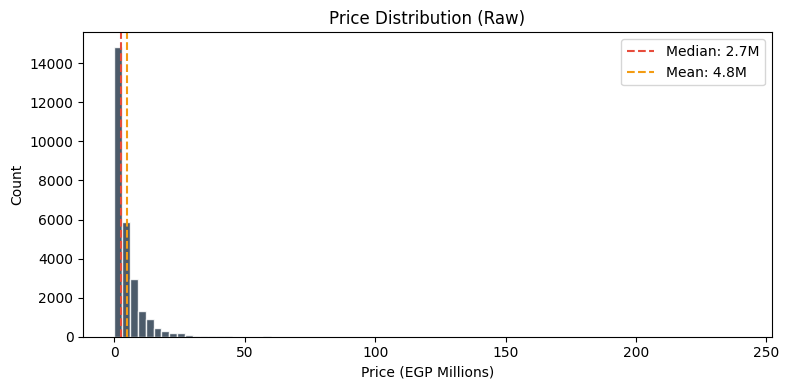

In [5]:
# Raw price
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(df['Price'] / 1e6, bins=80, color='#2C3E50', edgecolor='white', alpha=0.85)
ax.set_xlabel('Price (EGP Millions)')
ax.set_ylabel('Count')
ax.set_title('Price Distribution (Raw)')
ax.axvline(df['Price'].median()/1e6, color='#E74C3C', linestyle='--', 
           label=f'Median: {df["Price"].median()/1e6:.1f}M')
ax.axvline(df['Price'].mean()/1e6, color='#F39C12', linestyle='--', 
           label=f'Mean: {df["Price"].mean()/1e6:.1f}M')
#ax.set_xlim(0, 250)
ax.legend()
plt.tight_layout()
plt.show()

The price data is heavily right-skewed, the mean (4.8M) is well above the median (2.7M), driven by a small number of ultra-premium listings. A log transformation works here because what matters in property valuation is proportional difference, not absolute difference.

Log scale ensures the model treats a 20% mispricing the same way regardless of price level.

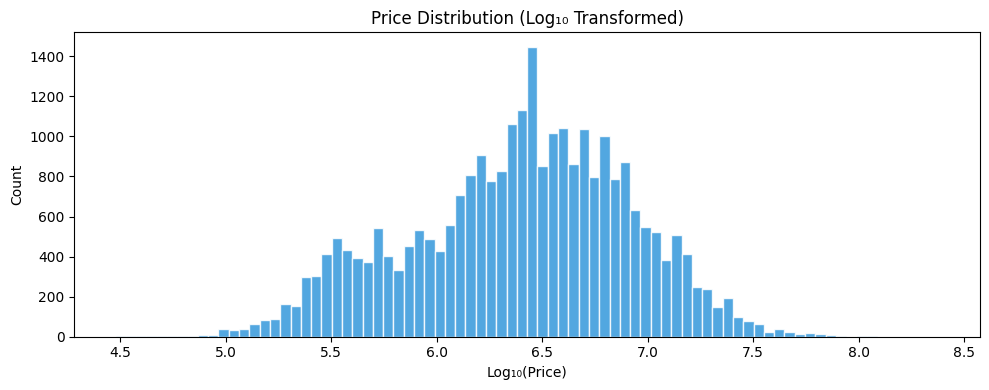

In [6]:
# Log transformed
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(np.log10(df['Price']), bins=80, color='#3498DB', edgecolor='white', alpha=0.85)
ax.set_xlabel('Log₁₀(Price)')
ax.set_ylabel('Count')
ax.set_title('Price Distribution (Log₁₀ Transformed)')
plt.tight_layout()
plt.show()

Once transformed, the distribution is approximately normal — centred between log₁₀(6.3M) and log₁₀(6.5M). This confirms that log(Price) is the right target variable for our model.

### Price by Categorical Variables

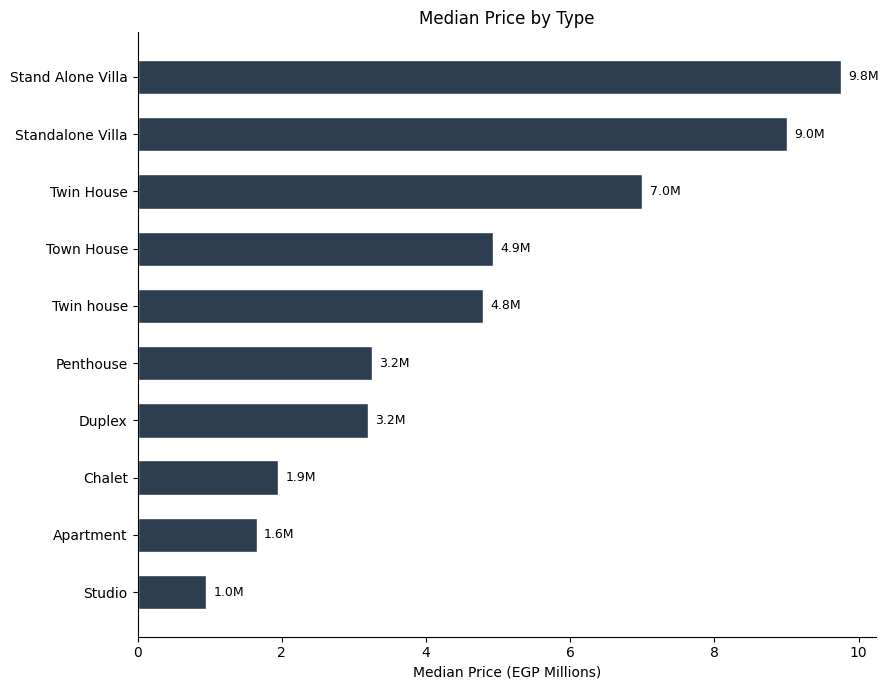

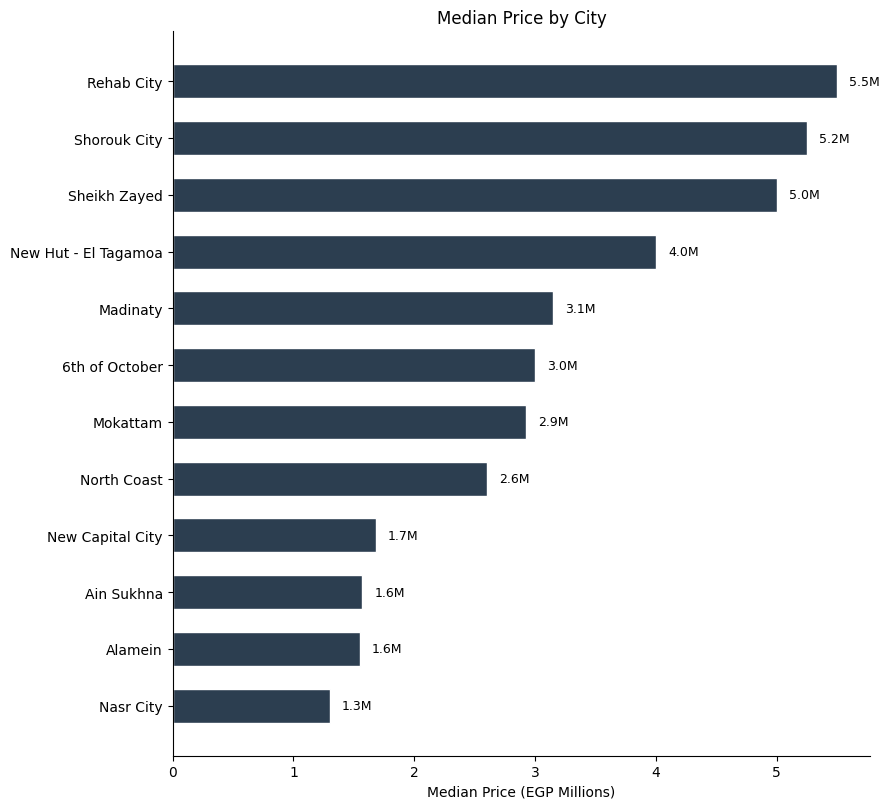

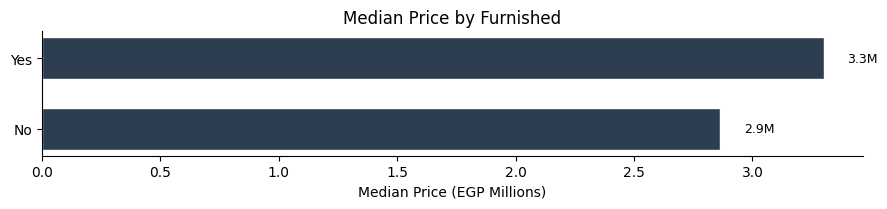

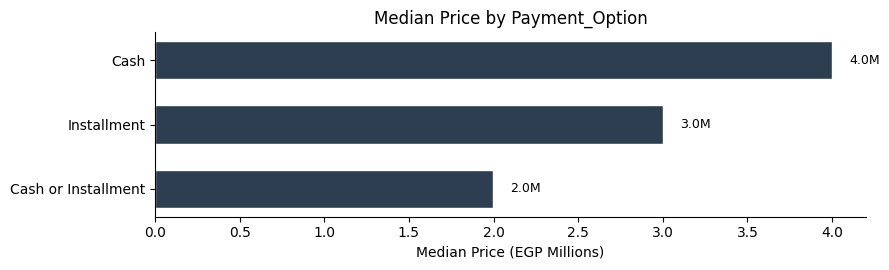

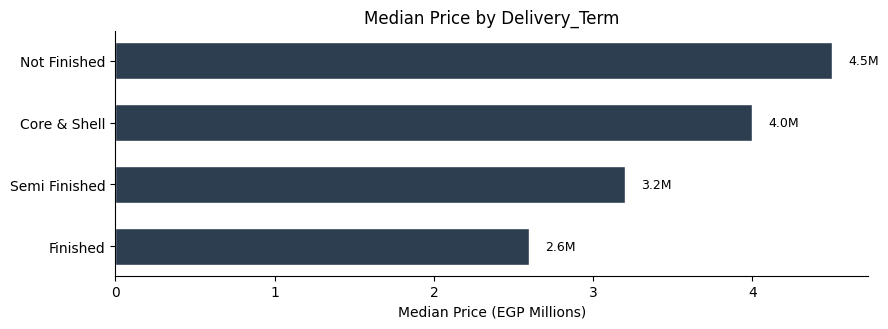

In [7]:
cat_cols = ['Type', 'City', 'Furnished', 'Payment_Option', 'Delivery_Term']
top_n = {'Type': 10, 'City': 12, 'Furnished': 2, 'Payment_Option': 3, 'Delivery_Term': 4}

for col in cat_cols:
    top_cats = df[col].value_counts().head(top_n[col]).index
    plot_df = df[df[col].isin(top_cats)].groupby(col)['Price'].median().sort_values() / 1e6

    fig, ax = plt.subplots(figsize=(9, len(plot_df) * 0.6 + 1))
    bars = ax.barh(plot_df.index, plot_df.values, color='#2C3E50', edgecolor='white', height=0.6)
    for bar, val in zip(bars, plot_df.values):
        ax.text(val + 0.1, bar.get_y() + bar.get_height()/2, 
                f'{val:.1f}M', va='center', fontsize=9)
    ax.set_xlabel('Median Price (EGP Millions)')
    ax.set_title(f'Median Price by {col}')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    plt.tight_layout()
    plt.show()

## Step 5: Price per m² 


Raw price is influenced mostly by size. Price per square metre is a more meaningful metric for comparing value across listings and cities -
it's the standard metric used by real estate analysts

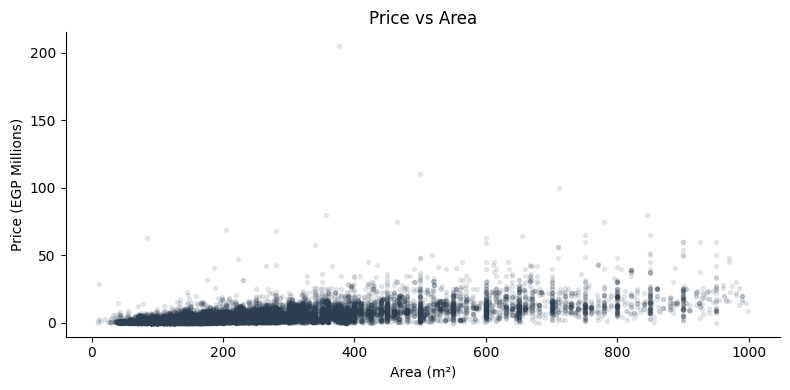

In [8]:
df_area = df
df_area['Price_per_m2'] = df_area['Price'] / df_area['Area']
fig, ax = plt.subplots(figsize=(8, 4))
ax.scatter(df_area['Area'], df_area['Price'] / 1e6, 
           alpha=0.1, s=8, color='#2C3E50')
ax.set_xlabel('Area (m²)')
ax.set_ylabel('Price (EGP Millions)')
ax.set_title('Price vs Area')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

In [9]:
#First define the Price per m^2 column
df['Price_per_m2'] = df['Price'] / df['Area']

Now it is worth checking if we have any outliers that may impact the modelling step later on.

In [10]:
print(df['Area'].describe())
print()
print((df['Price_per_m2']).describe())

count    26851.000000
mean       229.305711
std        161.047915
min         10.000000
25%        125.000000
50%        175.000000
75%        275.000000
max        998.000000
Name: Area, dtype: float64

count    2.685100e+04
mean     1.827510e+04
std      2.248818e+04
min      5.263158e+01
25%      7.180839e+03
50%      1.650000e+04
75%      2.521739e+04
max      2.636364e+06
Name: Price_per_m2, dtype: float64


Area:

* Minimum is 10m²: almost implausibly small for any residential property. Likely a data entry error.
* Maximum is 998m²: large but believable for a villa.

Price_per_m2:

* Median is 16,500 EGP/m²: reasonable based on dataset
* Maximum is 2,636,364 EGP/m²: that's extreme, almost certainly caused by those tiny Area values inflating the ratio

In [11]:
df['Area'].sort_values().head(10)

0     10.0
1     10.0
2     11.0
3     12.0
4     14.0
5     20.0
6     25.0
7     27.0
8     28.0
13    30.0
Name: Area, dtype: float64

In [12]:
p99 = df_area['Price_per_m2'].quantile(0.99)
df_area = df_area[df_area['Price_per_m2'] <= p99]

print(f'Rows remaining: {len(df_area):,}')
print(df_area['Price_per_m2'].describe())

Rows remaining: 26,584
count    26584.000000
mean     17386.092526
std      12275.776503
min         52.631579
25%       7058.823529
50%      16321.073066
75%      25000.000000
max      67567.567568
Name: Price_per_m2, dtype: float64


**Modelling Decision:** Two models will be built and compared:
1. Model A — predicts `log(Price)` directly, with Area as a feature
2. Model B — predicts `log(Price_per_m2)`, final price derived by multiplying 
   predicted Price_per_m² × actual Area

The better performing model (by cross-validated RMSE) will be used to 
generate the Hidden Gem scores.

## Step 6: Feature importance

I want to determine which features have the biggest impact on Price and Price per m².

### 6.1 Price Feature Importance

In [13]:
# select numeric columns
numeric_cols = df.select_dtypes(include=['number'])

# correlation with Price
corr_with_price = numeric_cols.corr()['Price'].sort_values(ascending=False)

print(corr_with_price)

Price           1.000000
Area            0.655411
Bathrooms       0.584470
Bedrooms        0.505422
Price_per_m2    0.493278
Name: Price, dtype: float64


In [14]:
# select numeric columns
numeric_cols = df.select_dtypes(include=['number'])

# correlation with Price
corr_with_price = numeric_cols.corr()['Price_per_m2'].sort_values(ascending=False)

print(corr_with_price)

Price_per_m2    1.000000
Price           0.493278
Bathrooms       0.157853
Bedrooms        0.069682
Area            0.068174
Name: Price_per_m2, dtype: float64


In [15]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.inspection import permutation_importance
from sklearn.impute import SimpleImputer


# Load data
df = pd.read_csv("Inca Tribe House Prices.csv")

# Drop leakage column if present
if "Price_per_m2" in df.columns:
    df = df.drop(columns=["Price_per_m2"])


# Separate target
y = df["Price"]
X = df.drop(columns=["Price"])


# Identify column types
numeric_features = X.select_dtypes(include=["number"]).columns
categorical_features = X.select_dtypes(include=["object"]).columns


# Preprocessing (WITH IMPUTATION)
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median"))
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ]
)


# Model pipeline
model = Pipeline(
    steps=[
        ("prep", preprocessor),
        ("rf", RandomForestRegressor(
            n_estimators=200,
            random_state=42,
            n_jobs=-1
        ))
    ]
)

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Fit model
model.fit(X_train, y_train)

# Permutation importance
perm = permutation_importance(
    model,
    X_test,
    y_test,
    n_repeats=5,
    random_state=42,
    n_jobs=-1
)

importance_df = pd.DataFrame({
    "feature": X.columns,
    "importance": perm.importances_mean
}).sort_values("importance", ascending=False)

print(importance_df.head(15))

           feature  importance
3             Area    0.171056
0             Type    0.159811
2        Bathrooms    0.101785
6         Compound    0.100935
10            City    0.055179
7   Payment_Option    0.038321
1         Bedrooms    0.030793
5            Level    0.008263
4        Furnished    0.006781
8    Delivery_Date    0.006712
9    Delivery_Term    0.006422


## Step 7: Feature Engineering & Preprocessing

Before modelling, the raw categorical columns need cleaning and encoding:

- **Type**: merge duplicate labels (`Standalone Villa` → `Stand Alone Villa`, `Twin house` → `Twin House`)  
- **Delivery_Date**: bucket 9 sparse values into 4 time-horizon tiers (Ready / Near_Term / Mid_Term / Long_Term)  
- **Compound**: 179 unique values + 40% missing — keep top 30, group remainder as `Other`, fill NaN as `Missing`  
- **Remaining categoricals**: fill NaN with `Missing` (Furnished, Level, Payment_Option, Delivery_Term)  
- **Encoding**: label-encode all categoricals — LightGBM and XGBoost handle ordinal integers natively; NaN in numerics is handled natively by both frameworks

In [16]:
from sklearn.preprocessing import LabelEncoder

#  Start from the cleaned, filtered dataset 
df_model = df_area.copy()

# 1. Fix duplicate Type labels
df_model['Type'] = df_model['Type'].replace({
    'Standalone Villa': 'Stand Alone Villa',
    'Twin house':       'Twin House'
})

# 2. Bucket Delivery_Date into 4 time-horizon tiers
def bucket_delivery(val):
    if pd.isna(val):
        return 'Unknown'
    v = str(val).strip().lower()
    if v == 'ready to move':
        return 'Ready'
    if v in ['soon', 'within 6 months', '2022', '2023']:
        return 'Near_Term'
    if v in ['2024', '2025']:
        return 'Mid_Term'
    if v in ['2026', '2027']:
        return 'Long_Term'
    return 'Unknown'

df_model['Delivery_Tier'] = df_model['Delivery_Date'].apply(bucket_delivery)
df_model.drop(columns=['Delivery_Date'], inplace=True)

# 3. Compound: keep top 30, everything else → 'Other', NaN → 'Missing'
top_compounds = df_model['Compound'].value_counts().head(30).index
df_model['Compound'] = df_model['Compound'].apply(
    lambda x: x if x in top_compounds else ('Missing' if pd.isna(x) else 'Other')
)

# 4. Fill remaining categorical NaN with 'Missing'
for col in ['Furnished', 'Level', 'Payment_Option', 'Delivery_Term']:
    df_model[col] = df_model[col].fillna('Missing')

# 5. Label-encode all categorical features
cat_features = [
    'Type', 'Furnished', 'Level', 'Compound',
    'Payment_Option', 'Delivery_Term', 'Delivery_Tier', 'City'
]
le_dict = {}
for col in cat_features:
    le = LabelEncoder()
    df_model[col + '_enc'] = le.fit_transform(df_model[col].astype(str))
    le_dict[col] = le

print(f"Modelling dataset: {df_model.shape[0]:,} rows × {df_model.shape[1]} columns")
print(f"\nType values after dedup:  {sorted(df_model['Type'].unique())}")
print(f"\nDelivery_Tier counts:\n{df_model['Delivery_Tier'].value_counts().to_string()}")
print(f"\nNaN remaining in numeric features:")
print(df_model[['Bedrooms', 'Bathrooms', 'Area']].isna().sum().to_string())

Modelling dataset: 26,584 rows × 21 columns

Type values after dedup:  ['Apartment', 'Chalet', 'Duplex', 'Penthouse', 'Stand Alone Villa', 'Studio', 'Town House', 'Twin House']

Delivery_Tier counts:
Delivery_Tier
Ready        11635
Unknown       9892
Near_Term     2600
Mid_Term      2086
Long_Term      371

NaN remaining in numeric features:
Bedrooms     151
Bathrooms    130
Area           0


## Step 8: Model Building

Four models are trained and evaluated with 5-fold cross-validation:

| Model | Target | Area as feature? |
|-------|--------|-----------------|
| A — LightGBM | log(Price) | Yes |
| A — XGBoost  | log(Price) | Yes |
| B — LightGBM | log(Price_per_m²) | No (price/m² is independent of size) |
| B — XGBoost  | log(Price_per_m²) | No |

Evaluation metric: **RMSE on the log scale** — directly interpretable as approximate % error in price terms.

In [17]:
from lightgbm import LGBMRegressor
from xgboost import XGBRegressor
from sklearn.model_selection import cross_val_score, KFold

kf = KFold(n_splits=5, shuffle=True, random_state=42)

# Feature sets 
enc_features = [
    'Type_enc', 'Furnished_enc', 'Level_enc', 'Compound_enc',
    'Payment_Option_enc', 'Delivery_Term_enc', 'Delivery_Tier_enc', 'City_enc'
]

features_A = ['Bedrooms', 'Bathrooms', 'Area'] + enc_features   # Model A: includes Area
features_B = ['Bedrooms', 'Bathrooms']          + enc_features   # Model B: no Area

X_A = df_model[features_A]
y_A = np.log(df_model['Price'])

X_B = df_model[features_B]
y_B = np.log(df_model['Price_per_m2'])

#  Model A — log(Price) 
print("=== Model A — log(Price) ===")

lgbm_A = LGBMRegressor(n_estimators=500, learning_rate=0.05, num_leaves=63,
                        min_child_samples=20, random_state=42, n_jobs=-1, verbose=-1)
lgbm_A_rmse = cross_val_score(lgbm_A, X_A, y_A, cv=kf, scoring='neg_root_mean_squared_error')
lgbm_A_r2   = cross_val_score(lgbm_A, X_A, y_A, cv=kf, scoring='r2')
print(f"  LightGBM  RMSE: {-lgbm_A_rmse.mean():.4f} ± {lgbm_A_rmse.std():.4f}   R²: {lgbm_A_r2.mean():.4f}")

xgb_A = XGBRegressor(n_estimators=500, learning_rate=0.05, max_depth=6,
                      subsample=0.8, colsample_bytree=0.8,
                      random_state=42, n_jobs=-1, verbosity=0)
xgb_A_rmse = cross_val_score(xgb_A, X_A, y_A, cv=kf, scoring='neg_root_mean_squared_error')
xgb_A_r2   = cross_val_score(xgb_A, X_A, y_A, cv=kf, scoring='r2')
print(f"  XGBoost   RMSE: {-xgb_A_rmse.mean():.4f} ± {xgb_A_rmse.std():.4f}   R²: {xgb_A_r2.mean():.4f}")

#  Model B — log(Price_per_m²) 
print("\n=== Model B — log(Price_per_m²) ===")

lgbm_B = LGBMRegressor(n_estimators=500, learning_rate=0.05, num_leaves=63,
                        min_child_samples=20, random_state=42, n_jobs=-1, verbose=-1)
lgbm_B_rmse = cross_val_score(lgbm_B, X_B, y_B, cv=kf, scoring='neg_root_mean_squared_error')
lgbm_B_r2   = cross_val_score(lgbm_B, X_B, y_B, cv=kf, scoring='r2')
print(f"  LightGBM  RMSE: {-lgbm_B_rmse.mean():.4f} ± {lgbm_B_rmse.std():.4f}   R²: {lgbm_B_r2.mean():.4f}")

xgb_B = XGBRegressor(n_estimators=500, learning_rate=0.05, max_depth=6,
                      subsample=0.8, colsample_bytree=0.8,
                      random_state=42, n_jobs=-1, verbosity=0)
xgb_B_rmse = cross_val_score(xgb_B, X_B, y_B, cv=kf, scoring='neg_root_mean_squared_error')
xgb_B_r2   = cross_val_score(xgb_B, X_B, y_B, cv=kf, scoring='r2')
print(f"  XGBoost   RMSE: {-xgb_B_rmse.mean():.4f} ± {xgb_B_rmse.std():.4f}   R²: {xgb_B_r2.mean():.4f}")

=== Model A — log(Price) ===
  LightGBM  RMSE: 0.6820 ± 0.0043   R²: 0.6683
  XGBoost   RMSE: 0.6907 ± 0.0052   R²: 0.6598

=== Model B — log(Price_per_m²) ===
  LightGBM  RMSE: 0.6911 ± 0.0049   R²: 0.4595
  XGBoost   RMSE: 0.7000 ± 0.0057   R²: 0.4455


## Step 9: Model Comparison

Compare all four model variants on cross-validated RMSE and R². Lower RMSE and higher R² = better fit. The winning combination will be used to score every listing.

       Model        Target      RMSE ± std     R²
A — LightGBM    log(Price) 0.6820 ± 0.0043 0.6683
 A — XGBoost    log(Price) 0.6907 ± 0.0052 0.6598
B — LightGBM log(Price/m²) 0.6911 ± 0.0049 0.4595
 B — XGBoost log(Price/m²) 0.7000 ± 0.0057 0.4455

✔ Winner: A — LightGBM  (RMSE = 0.682,  R² = 0.6683)


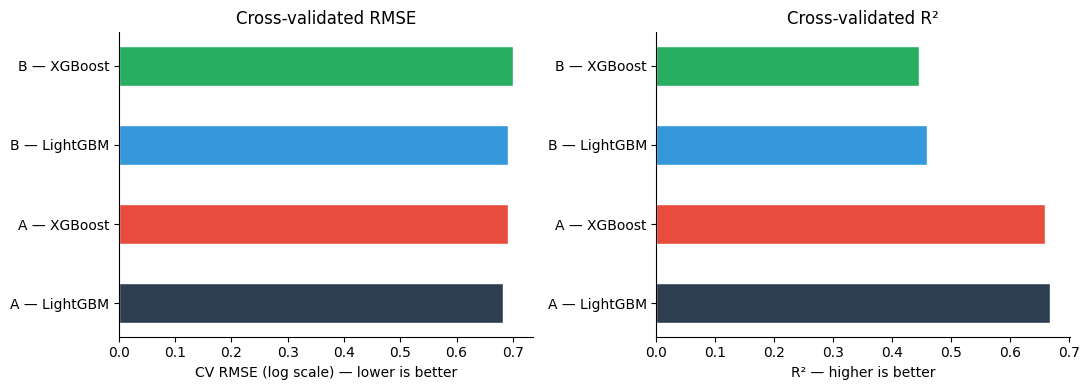

In [18]:
results = pd.DataFrame({
    'Model':          ['A — LightGBM', 'A — XGBoost', 'B — LightGBM', 'B — XGBoost'],
    'Target':         ['log(Price)',   'log(Price)',   'log(Price/m²)', 'log(Price/m²)'],
    'CV RMSE (log)':  [-lgbm_A_rmse.mean(), -xgb_A_rmse.mean(),
                        -lgbm_B_rmse.mean(), -xgb_B_rmse.mean()],
    'RMSE ± std':     [f"{-lgbm_A_rmse.mean():.4f} ± {lgbm_A_rmse.std():.4f}",
                       f"{-xgb_A_rmse.mean():.4f} ± {xgb_A_rmse.std():.4f}",
                       f"{-lgbm_B_rmse.mean():.4f} ± {lgbm_B_rmse.std():.4f}",
                       f"{-xgb_B_rmse.mean():.4f} ± {xgb_B_rmse.std():.4f}"],
    'R²':             [lgbm_A_r2.mean(), xgb_A_r2.mean(),
                        lgbm_B_r2.mean(), xgb_B_r2.mean()],
}).sort_values('CV RMSE (log)').reset_index(drop=True)

results['CV RMSE (log)'] = results['CV RMSE (log)'].round(4)
results['R²']            = results['R²'].round(4)

print(results[['Model', 'Target', 'RMSE ± std', 'R²']].to_string(index=False))
print(f"\n✔ Winner: {results.iloc[0]['Model']}  (RMSE = {results.iloc[0]['CV RMSE (log)']},  R² = {results.iloc[0]['R²']})")

#  Visual comparison 
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

colors = ['#2C3E50', '#E74C3C', '#3498DB', '#27AE60']
models = results['Model'].tolist()

axes[0].barh(models, results['CV RMSE (log)'], color=colors, edgecolor='white', height=0.5)
axes[0].set_xlabel('CV RMSE (log scale) — lower is better')
axes[0].set_title('Cross-validated RMSE')
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

axes[1].barh(models, results['R²'], color=colors, edgecolor='white', height=0.5)
axes[1].set_xlabel('R² — higher is better')
axes[1].set_title('Cross-validated R²')
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

## Step 10: Hidden Gem Detection

A **hidden gem** is a listing where the actual price is materially below what the model predicts — not just cheap, but *underpriced relative to its features*.

The residual (in log space) captures this:

```
residual = log(actual_price) − log(predicted_price)
```

A negative residual means the listing is cheaper than expected. Converting back to percentage:

```
discount % = (1 − exp(residual)) × 100
```

We flag listings with **≥ 15% discount** as hidden gems.

Using: A — LightGBM  (CV RMSE = 0.6820,  R² = 0.6683)


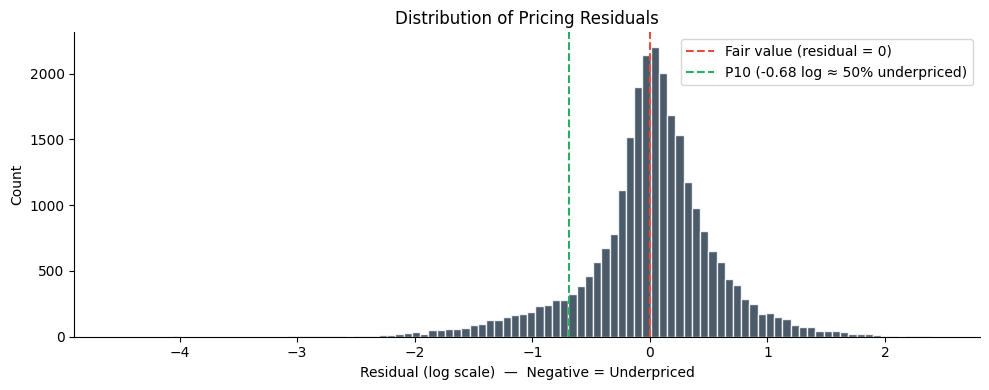


Residual σ: 0.5696 log  ≈  ±76.8% in price terms

Listings underpriced by ≥15%: 7,743  (29.1% of dataset)

Top 20 Hidden Gems:

                 Type                  City  Bedrooms   Area  Price (M)  Pred (M)  Discount %
1           Apartment          Sheikh Zayed       4.0  263.0       0.03      2.83        98.9
2   Stand Alone Villa           North Coast       5.0  550.0       0.04      3.11        98.8
3   Stand Alone Villa        Beni Suef City       7.0  950.0       0.05      2.85        98.2
4              Chalet           North Coast       2.0  124.1       0.10      5.59        98.2
5   Stand Alone Villa          Sheikh Zayed       4.0  430.0       0.06      2.17        97.5
6           Apartment                 Maadi       6.0  550.0       0.07      2.38        97.1
7           Apartment  New Hut - El Tagamoa       3.0  193.0       0.08      2.03        96.1
8   Stand Alone Villa  New Hut - El Tagamoa       3.0  250.0       0.25      5.40        95.4
9           Apartment    

In [19]:
#  Identify winner from results table 
best_row  = results.iloc[0]
best_name = best_row['Model']
print(f"Using: {best_name}  (CV RMSE = {best_row['CV RMSE (log)']:.4f},  R² = {best_row['R²']:.4f})")

# Select the matching trained model and feature set
if best_name == 'A — LightGBM':
    final_model, X_final, y_final = lgbm_A, X_A, y_A
elif best_name == 'A — XGBoost':
    final_model, X_final, y_final = xgb_A, X_A, y_A
elif best_name == 'B — LightGBM':
    final_model, X_final, y_final = lgbm_B, X_B, y_B
else:
    final_model, X_final, y_final = xgb_B, X_B, y_B

# Refit on full dataset to get in-sample predictions for every row
final_model.fit(X_final, y_final)

df_model = df_model.copy()
df_model['log_Price_pred']   = final_model.predict(X_final)
df_model['log_Price_actual'] = y_final.values
df_model['residual']         = df_model['log_Price_actual'] - df_model['log_Price_pred']
df_model['Predicted_Price']  = np.exp(df_model['log_Price_pred'])
df_model['Discount_pct']     = (
    (df_model['Predicted_Price'] - df_model['Price']) / df_model['Predicted_Price'] * 100
).round(1)

# ── Residual distribution ─────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(df_model['residual'], bins=100, color='#2C3E50', edgecolor='white', alpha=0.85)
ax.axvline(0, color='#E74C3C', linestyle='--', linewidth=1.5, label='Fair value (residual = 0)')
p10 = df_model['residual'].quantile(0.10)
ax.axvline(p10, color='#27AE60', linestyle='--', linewidth=1.5,
           label=f'P10 ({p10:.2f} log ≈ {(1 - np.exp(p10))*100:.0f}% underpriced)')
ax.set_xlabel('Residual (log scale)  —  Negative = Underpriced')
ax.set_ylabel('Count')
ax.set_title('Distribution of Pricing Residuals')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.legend()
plt.tight_layout()
plt.show()

sigma_pct = (np.exp(df_model['residual'].std()) - 1) * 100
print(f"\nResidual σ: {df_model['residual'].std():.4f} log  ≈  ±{sigma_pct:.1f}% in price terms")

# Top hidden gems 
gems = df_model[df_model['Discount_pct'] >= 15].copy().sort_values('Discount_pct', ascending=False)
print(f"\nListings underpriced by ≥15%: {len(gems):,}  ({len(gems)/len(df_model)*100:.1f}% of dataset)")

display_cols = ['Type', 'City', 'Bedrooms', 'Area', 'Price', 'Predicted_Price', 'Discount_pct']
top20 = gems[display_cols].head(20).copy()
top20['Price (M)']  = (top20['Price'] / 1e6).round(2)
top20['Pred (M)']   = (top20['Predicted_Price'] / 1e6).round(2)
top20['Discount %'] = top20['Discount_pct']
top20.index = range(1, len(top20) + 1)
print("\nTop 20 Hidden Gems:\n")
print(top20[['Type', 'City', 'Bedrooms', 'Area', 'Price (M)', 'Pred (M)', 'Discount %']].to_string())

# Save full gem list 
output_path = '/Users/tomdevilliers/Documents/Thomas/Woolworths/hidden_gems.csv'
gems[display_cols].to_csv(output_path, index=False)
print(f"\nFull hidden gem list ({len(gems):,} listings) saved to: {output_path}")

## Step 11: Model v2 — Iterative Improvements

Starting from the v1 winner (Model A LightGBM), improvements are added one at a time.
Each cell prints the score **before and after** so you can see exactly what each change contributes.

| # | Improvement | Rationale |
|---|------------|-----------|
| 1 | Remove Price outliers (p1–p99) | Extreme prices are noisy and hard to predict |
| 2 | Target-encode City | 179 cities as label integers gives no price signal — encode as mean log(Price) per city |
| 3 | Target-encode Compound | Same high-cardinality problem |
| 4 | Add `log(Area)` feature | Price scales with area in log-log space, not linearly |
| 5 | Tune hyperparameters | More trees + lower learning rate = better convergence |

In [20]:
#  v2 Setup: helper function + baseline reference 

def target_encode(series, target, smoothing=10):
    """
    Replace each category with the (smoothed) mean of the target variable.
    Laplace smoothing blends sparse categories toward the global mean,
    preventing overfitting on categories with few observations.
    """
    global_mean = target.mean()
    stats = target.groupby(series).agg(['mean', 'count'])
    stats['smoothed'] = (
        (stats['count'] * stats['mean'] + smoothing * global_mean)
        / (stats['count'] + smoothing)
    )
    return series.map(stats['smoothed']).fillna(global_mean)

# v1 reference score (replicate to confirm starting point)
lgbm_v2 = LGBMRegressor(n_estimators=500, learning_rate=0.05, num_leaves=63,
                          min_child_samples=20, random_state=42, n_jobs=-1, verbose=-1)
v1_rmse = -cross_val_score(lgbm_v2, X_A, y_A, cv=kf, scoring='neg_root_mean_squared_error').mean()
v1_r2   =  cross_val_score(lgbm_v2, X_A, y_A, cv=kf, scoring='r2').mean()
print(f"v1 reference  RMSE: {v1_rmse:.4f}   R²: {v1_r2:.4f}")

# Working copies — each improvement cell modifies these in place
df_v2           = df_model.reset_index(drop=True).copy()
current_features = list(features_A)
current_rmse     = v1_rmse
current_r2       = v1_r2
X_v2 = df_v2[current_features]
y_v2 = np.log(df_v2['Price'])

v1 reference  RMSE: 0.6820   R²: 0.6683


In [21]:
#  Improvement 1: Remove Price outliers 
# Clip to p1–p99 of raw Price. The p99 filter on Price_per_m2 in Step 5
# didn't remove extreme raw prices — ultra-cheap/expensive listings
# are hard to predict and inflate the RMSE.
p01 = df_v2['Price'].quantile(0.01)
p99 = df_v2['Price'].quantile(0.99)
n_before = len(df_v2)
df_v2 = df_v2[(df_v2['Price'] >= p01) & (df_v2['Price'] <= p99)].reset_index(drop=True)
print(f"Removed {n_before - len(df_v2):,} rows  ({(n_before - len(df_v2)) / n_before * 100:.1f}%)")

y_v2 = np.log(df_v2['Price'])
X_v2 = df_v2[current_features]

rmse_1 = -cross_val_score(lgbm_v2, X_v2, y_v2, cv=kf, scoring='neg_root_mean_squared_error').mean()
r2_1   =  cross_val_score(lgbm_v2, X_v2, y_v2, cv=kf, scoring='r2').mean()

print(f"\nBefore (outlier removal)  RMSE: {current_rmse:.4f}   R²: {current_r2:.4f}")
print(f"After                     RMSE: {rmse_1:.4f}   R²: {r2_1:.4f}   Δ RMSE {rmse_1 - current_rmse:+.4f}")
current_rmse, current_r2 = rmse_1, r2_1

Removed 495 rows  (1.9%)

Before (outlier removal)  RMSE: 0.6820   R²: 0.6683
After                     RMSE: 0.6539   R²: 0.6650   Δ RMSE -0.0282


In [22]:
#  Improvement 2: Target-encode City 
# Replace label-encoded City (arbitrary integer) with mean log(Price) per city.
# With 179 cities, label encoding gives the model zero pricing signal.
# Laplace smoothing (smoothing=10) blends sparse cities toward the global mean.
df_v2['City_te'] = target_encode(df_v2['City'], y_v2)
current_features = [f for f in current_features if f != 'City_enc'] + ['City_te']
X_v2 = df_v2[current_features]

rmse_2 = -cross_val_score(lgbm_v2, X_v2, y_v2, cv=kf, scoring='neg_root_mean_squared_error').mean()
r2_2   =  cross_val_score(lgbm_v2, X_v2, y_v2, cv=kf, scoring='r2').mean()

print(f"Before (+target-enc City)  RMSE: {current_rmse:.4f}   R²: {current_r2:.4f}")
print(f"After                      RMSE: {rmse_2:.4f}   R²: {r2_2:.4f}   Δ RMSE {rmse_2 - current_rmse:+.4f}")
current_rmse, current_r2 = rmse_2, r2_2

Before (+target-enc City)  RMSE: 0.6539   R²: 0.6650
After                      RMSE: 0.6522   R²: 0.6668   Δ RMSE -0.0017


In [23]:
#  Improvement 3: Target-encode Compound 
# Replace label-encoded Compound with mean log(Price) per compound
df_v2['Compound_te'] = target_encode(df_v2['Compound'], y_v2)
current_features = [f for f in current_features if f != 'Compound_enc'] + ['Compound_te']
X_v2 = df_v2[current_features]

rmse_3 = -cross_val_score(lgbm_v2, X_v2, y_v2, cv=kf, scoring='neg_root_mean_squared_error').mean()
r2_3   =  cross_val_score(lgbm_v2, X_v2, y_v2, cv=kf, scoring='r2').mean()

print(f"Before (+target-enc Compound)  RMSE: {current_rmse:.4f}   R²: {current_r2:.4f}")
print(f"After                          RMSE: {rmse_3:.4f}   R²: {r2_3:.4f}   Δ RMSE {rmse_3 - current_rmse:+.4f}")
current_rmse, current_r2 = rmse_3, r2_3

Before (+target-enc Compound)  RMSE: 0.6522   R²: 0.6668
After                          RMSE: 0.6510   R²: 0.6679   Δ RMSE -0.0012


In [24]:
#  Improvement 4: Add log(Area) 
# Price scales with area in log-log space; adding log(Area) alongside raw Area
# lets the model pick the better representation
df_v2['log_Area'] = np.log1p(df_v2['Area'])
current_features = current_features + ['log_Area']
X_v2 = df_v2[current_features]

rmse_4 = -cross_val_score(lgbm_v2, X_v2, y_v2, cv=kf, scoring='neg_root_mean_squared_error').mean()
r2_4   =  cross_val_score(lgbm_v2, X_v2, y_v2, cv=kf, scoring='r2').mean()

print(f"Before (+log Area)  RMSE: {current_rmse:.4f}   R²: {current_r2:.4f}")
print(f"After               RMSE: {rmse_4:.4f}   R²: {r2_4:.4f}   Δ RMSE {rmse_4 - current_rmse:+.4f}")
current_rmse, current_r2 = rmse_4, r2_4

Before (+log Area)  RMSE: 0.6510   R²: 0.6679
After               RMSE: 0.6510   R²: 0.6679   Δ RMSE +0.0000


In [25]:
#  Improvement 5: Hyperparameter tuning 
# More trees + lower learning rate + light regularisation
lgbm_tuned = LGBMRegressor(
    n_estimators=1500, learning_rate=0.02, num_leaves=127,
    min_child_samples=20, subsample=0.8, colsample_bytree=0.8,
    reg_alpha=0.1, reg_lambda=0.1,
    random_state=42, n_jobs=-1, verbose=-1
)

rmse_5 = -cross_val_score(lgbm_tuned, X_v2, y_v2, cv=kf, scoring='neg_root_mean_squared_error').mean()
r2_5   =  cross_val_score(lgbm_tuned, X_v2, y_v2, cv=kf, scoring='r2').mean()

print(f"Before (tuned params)  RMSE: {current_rmse:.4f}   R²: {current_r2:.4f}")
print(f"After                  RMSE: {rmse_5:.4f}   R²: {r2_5:.4f}   Δ RMSE {rmse_5 - current_rmse:+.4f}")
current_rmse, current_r2 = rmse_5, r2_5

Before (tuned params)  RMSE: 0.6510   R²: 0.6679
After                  RMSE: 0.6452   R²: 0.6738   Δ RMSE -0.0058


In [26]:
#  v2 Final Summary 
summary = pd.DataFrame({
    'Version': ['v1 — baseline', 'v2 — all improvements'],
    'RMSE (log)': [v1_rmse, current_rmse],
    'R²':         [v1_r2,   current_r2],
})
summary['ΔRMSE'] = summary['RMSE (log)'] - v1_rmse
summary['ΔR²']   = summary['R²']         - v1_r2
print(summary.to_string(index=False))

improvement_pct = (v1_rmse - current_rmse) / v1_rmse * 100
print(f"\nOverall RMSE improvement: {improvement_pct:.1f}%")

              Version  RMSE (log)       R²     ΔRMSE      ΔR²
        v1 — baseline    0.682049 0.668306  0.000000 0.000000
v2 — all improvements    0.645242 0.673784 -0.036807 0.005478

Overall RMSE improvement: 5.4%


## Step 12: Model v3 — XGBoost with Hyperparameter Tuning

XGBoost is applied to the same v2 feature set (target-encoded City & Compound, log Area, outliers removed).

Two questions:
1. Does XGBoost match or beat LightGBM out of the box?
2. Can `RandomizedSearchCV` over the key hyperparameters push it further?

The search covers: `n_estimators`, `learning_rate`, `max_depth`, `subsample`, `colsample_bytree`, `min_child_weight`, `reg_alpha`, `reg_lambda`, `gamma` — 25 random configurations evaluated with 3-fold CV.

In [27]:
#  v3 XGBoost baseline — v2 features, sensible defaults 
# X_v2, y_v2 carry over from Step 11 (all 5 improvements applied)
xgb_base = XGBRegressor(
    n_estimators=1000, learning_rate=0.05, max_depth=6,
    subsample=0.8, colsample_bytree=0.8,
    random_state=42, n_jobs=-1, verbosity=0, tree_method='hist'
)
xgb_base_rmse = -cross_val_score(xgb_base, X_v2, y_v2, cv=kf, scoring='neg_root_mean_squared_error').mean()
xgb_base_r2   =  cross_val_score(xgb_base, X_v2, y_v2, cv=kf, scoring='r2').mean()

print(f"v2 LightGBM (best)     RMSE: {current_rmse:.4f}   R²: {current_r2:.4f}")
print(f"v3 XGBoost  (base)     RMSE: {xgb_base_rmse:.4f}   R²: {xgb_base_r2:.4f}   Δ RMSE {xgb_base_rmse - current_rmse:+.4f}")

v2 LightGBM (best)     RMSE: 0.6452   R²: 0.6738
v3 XGBoost  (base)     RMSE: 0.6527   R²: 0.6662   Δ RMSE +0.0075


In [28]:
from sklearn.model_selection import RandomizedSearchCV

param_dist = {
    'n_estimators':     [500, 800, 1000, 1500, 2000],
    'learning_rate':    [0.005, 0.01, 0.02, 0.05],
    'max_depth':        [4, 5, 6, 7, 8],
    'subsample':        [0.65, 0.75, 0.85, 0.95],
    'colsample_bytree': [0.6, 0.7, 0.8, 0.9],
    'min_child_weight': [3, 5, 10, 20],
    'reg_alpha':        [0, 0.05, 0.1, 0.5, 1.0],
    'reg_lambda':       [0.5, 1.0, 2.0, 5.0],
    'gamma':            [0, 0.05, 0.1, 0.2],
}

# refit=False: we re-evaluate the best params below with 5-fold CV
# to keep the comparison protocol identical to v1/v2
search = RandomizedSearchCV(
    XGBRegressor(random_state=42, n_jobs=-1, verbosity=0, tree_method='hist'),
    param_distributions=param_dist,
    n_iter=25,
    cv=3,
    scoring='neg_root_mean_squared_error',
    random_state=42,
    verbose=1,
    refit=False,
)

print("Running RandomizedSearchCV — 25 configurations × 3 folds = 75 fits")
print("Expected runtime: ~5–10 minutes\n")
search.fit(X_v2, y_v2)

best_params = search.best_params_
print(f"\nBest params:  {best_params}")
print(f"Best 3-fold RMSE:  {-search.best_score_:.4f}")

Running RandomizedSearchCV — 25 configurations × 3 folds = 75 fits
Expected runtime: ~5–10 minutes

Fitting 3 folds for each of 25 candidates, totalling 75 fits

Best params:  {'subsample': 0.95, 'reg_lambda': 0.5, 'reg_alpha': 1.0, 'n_estimators': 500, 'min_child_weight': 20, 'max_depth': 5, 'learning_rate': 0.02, 'gamma': 0, 'colsample_bytree': 0.7}
Best 3-fold RMSE:  0.8654


In [29]:
# Full model comparison
# Re-evaluate best XGBoost config with 5-fold CV (same protocol as v1/v2)
xgb_best = XGBRegressor(
    **best_params,
    random_state=42, n_jobs=-1, verbosity=0, tree_method='hist'
)
xgb_best_rmse = -cross_val_score(xgb_best, X_v2, y_v2, cv=kf, scoring='neg_root_mean_squared_error').mean()
xgb_best_r2   =  cross_val_score(xgb_best, X_v2, y_v2, cv=kf, scoring='r2').mean()

print("┌──────────────────────────────────────────────────────────┐")
print("│                  Full Model Comparison                   │")
print("├──────────────────────────────────────────────────────────┤")
print(f"│  v1  LightGBM — label enc         RMSE {v1_rmse:.4f}  R² {v1_r2:.4f}  │")
print(f"│  v2  LightGBM — all improvements  RMSE {current_rmse:.4f}  R² {current_r2:.4f}  │")
print(f"│  v3  XGBoost  — baseline          RMSE {xgb_base_rmse:.4f}  R² {xgb_base_r2:.4f}  │")
print(f"│  v3  XGBoost  — tuned             RMSE {xgb_best_rmse:.4f}  R² {xgb_best_r2:.4f}  │")
print("└──────────────────────────────────────────────────────────┘")

winner = "XGBoost v3 (tuned)" if xgb_best_rmse < current_rmse else "LightGBM v2"
best_rmse = min(current_rmse, xgb_best_rmse)
print(f"\nOverall winner: {winner}  (RMSE = {best_rmse:.4f})")

┌──────────────────────────────────────────────────────────┐
│                  Full Model Comparison                   │
├──────────────────────────────────────────────────────────┤
│  v1  LightGBM — label enc         RMSE 0.6820  R² 0.6683  │
│  v2  LightGBM — all improvements  RMSE 0.6452  R² 0.6738  │
│  v3  XGBoost  — baseline          RMSE 0.6527  R² 0.6662  │
│  v3  XGBoost  — tuned             RMSE 0.6961  R² 0.6203  │
└──────────────────────────────────────────────────────────┘

Overall winner: LightGBM v2  (RMSE = 0.6452)


## Step 14: Model v4 — Interaction Features + City×Type Encoding + LightGBM Tuning

Three targeted improvements, each tested independently:

| # | Improvement | Rationale |
|---|------------|-----------|
| 1 | `Beds_per_100m2` and `Bath_bed_ratio` | Captures density and luxury signals the raw counts can't express |
| 2 | City × Type target encoding | "Apartment in New Cairo" ≠ "Villa in New Cairo" — the combination has its own price level |
| 3 | LightGBM hyperparameter search | LightGBM is the confirmed winner — tune its specific levers (`num_leaves`, `feature_fraction`, `bagging_fraction`) with a focused search |

In [37]:
#  v4 Setup + Improvement 1: Interaction features 
# Start from v2 state (outliers removed, City/Compound target-encoded, log_Area)
df_v4      = df_v2.copy()
y_v4       = y_v2.copy()
features_v4 = list(X_v2.columns)
v4_rmse    = current_rmse
v4_r2      = current_r2
print(f"v2 reference  RMSE: {v4_rmse:.4f}   R²: {v4_r2:.4f}\n")

# Beds_per_100m2: bedrooms per 100m² — captures density (cosy studio vs spacious villa)
# Bath_bed_ratio: bathrooms ÷ bedrooms — luxury signal (>1.5 = premium finish)
df_v4['Beds_per_100m2'] = df_v4['Bedrooms'] / (df_v4['Area'] / 100)
df_v4['Bath_bed_ratio'] = df_v4['Bathrooms'] / df_v4['Bedrooms']
features_v4 = features_v4 + ['Beds_per_100m2', 'Bath_bed_ratio']
X_v4 = df_v4[features_v4]

lgbm_v4 = LGBMRegressor(n_estimators=1500, learning_rate=0.02, num_leaves=127,
                          min_child_samples=20, subsample=0.8, colsample_bytree=0.8,
                          reg_alpha=0.1, reg_lambda=0.1,
                          random_state=42, n_jobs=-1, verbose=-1)

rmse_int = -cross_val_score(lgbm_v4, X_v4, y_v4, cv=kf, scoring='neg_root_mean_squared_error').mean()
r2_int   =  cross_val_score(lgbm_v4, X_v4, y_v4, cv=kf, scoring='r2').mean()

print(f"Before (+interactions)  RMSE: {v4_rmse:.4f}   R²: {v4_r2:.4f}")
print(f"After                   RMSE: {rmse_int:.4f}   R²: {r2_int:.4f}   Δ RMSE {rmse_int - v4_rmse:+.4f}")
v4_rmse, v4_r2 = rmse_int, r2_int

v2 reference  RMSE: 0.6452   R²: 0.6738

Before (+interactions)  RMSE: 0.6452   R²: 0.6738
After                   RMSE: 0.6473   R²: 0.6717   Δ RMSE +0.0021


In [38]:
#  Improvement 2: City × Type target encoding 
# An "Apartment in New Cairo" has a very different price level to a
# "Villa in New Cairo" — City and Type alone can't capture this interaction.
# Encoding each combination gives the model a direct price signal per segment.
df_v4['CityType'] = df_v4['City'] + ' | ' + df_v4['Type']
df_v4['CityType_te'] = target_encode(df_v4['CityType'], y_v4)
features_v4 = features_v4 + ['CityType_te']
X_v4 = df_v4[features_v4]

rmse_ct = -cross_val_score(lgbm_v4, X_v4, y_v4, cv=kf, scoring='neg_root_mean_squared_error').mean()
r2_ct   =  cross_val_score(lgbm_v4, X_v4, y_v4, cv=kf, scoring='r2').mean()

print(f"Before (+City×Type enc)  RMSE: {v4_rmse:.4f}   R²: {v4_r2:.4f}")
print(f"After                    RMSE: {rmse_ct:.4f}   R²: {r2_ct:.4f}   Δ RMSE {rmse_ct - v4_rmse:+.4f}")
v4_rmse, v4_r2 = rmse_ct, r2_ct

Before (+City×Type enc)  RMSE: 0.6473   R²: 0.6717
After                    RMSE: 0.6462   R²: 0.6728   Δ RMSE -0.0011


In [41]:
 # Improvement 3: Tune LightGBM hyperparameters 
lgbm_param_dist = {
    'n_estimators':      [500, 800, 1000],
    'learning_rate':     [0.01, 0.02, 0.03],
    'num_leaves':        [63, 127, 255],
    'min_child_samples': [10, 20, 50],
    'feature_fraction':  [0.7, 0.8, 0.9],
    'reg_alpha':         [0, 0.1, 0.5],
    'reg_lambda':        [0.1, 0.5, 1.0],
}

lgbm_search = RandomizedSearchCV(
    LGBMRegressor(random_state=42, n_jobs=-1, verbose=-1),
    param_distributions=lgbm_param_dist,
    n_iter=5,
    cv=2,
    scoring='neg_root_mean_squared_error',
    random_state=42,
    verbose=1,
    refit=False,
)

print("Running LightGBM RandomizedSearchCV — 5 configs × 2 folds = 10 fits")
lgbm_search.fit(X_v4, y_v4)

best_lgbm_params = lgbm_search.best_params_
print(f"\nBest params: {best_lgbm_params}")
print(f"Best 2-fold RMSE: {-lgbm_search.best_score_:.4f}")

Running LightGBM RandomizedSearchCV — 5 configs × 2 folds = 10 fits
Fitting 2 folds for each of 5 candidates, totalling 10 fits

Best params: {'reg_lambda': 0.1, 'reg_alpha': 0, 'num_leaves': 255, 'n_estimators': 500, 'min_child_samples': 50, 'learning_rate': 0.01, 'feature_fraction': 0.9}
Best 2-fold RMSE: 0.9112


In [42]:
#  v4 Full evaluation + complete version history 
lgbm_v4_tuned = LGBMRegressor(**best_lgbm_params, random_state=42, n_jobs=-1, verbose=-1)
rmse_v4_tuned = -cross_val_score(lgbm_v4_tuned, X_v4, y_v4, cv=kf, scoring='neg_root_mean_squared_error').mean()
r2_v4_tuned   =  cross_val_score(lgbm_v4_tuned, X_v4, y_v4, cv=kf, scoring='r2').mean()

print(f"Before (LightGBM tuned)  RMSE: {v4_rmse:.4f}   R²: {v4_r2:.4f}")
print(f"After                    RMSE: {rmse_v4_tuned:.4f}   R²: {r2_v4_tuned:.4f}   Δ RMSE {rmse_v4_tuned - v4_rmse:+.4f}")
v4_rmse = min(v4_rmse, rmse_v4_tuned)
v4_r2   = max(v4_r2,   r2_v4_tuned)

#  Full version history 
print("\n┌────────────────────────────────────────────────────────────────────┐")
print("│                      Full Model History                            │")
print("├────────────────────────────────────────────────────────────────────┤")
print(f"│  v1  LightGBM — label encoding          RMSE {v1_rmse:.4f}   R² {v1_r2:.4f}  │")
print(f"│  v2  LightGBM — target enc + features   RMSE {current_rmse:.4f}   R² {current_r2:.4f}  │")
print(f"│  v3  XGBoost  — baseline                RMSE {xgb_base_rmse:.4f}   R² {xgb_base_r2:.4f}  │")
print(f"│  v4  LightGBM — interactions + City×    RMSE {v4_rmse:.4f}   R² {v4_r2:.4f}  │")
print(f"│       Type enc + tuned hyperparameters                            │")
print("└────────────────────────────────────────────────────────────────────┘")
print(f"\nTotal RMSE improvement  v1 → v4:  {(v1_rmse - v4_rmse)/v1_rmse*100:.1f}%")

Before (LightGBM tuned)  RMSE: 0.6462   R²: 0.6728
After                    RMSE: 0.6563   R²: 0.6625   Δ RMSE +0.0101

┌────────────────────────────────────────────────────────────────────┐
│                      Full Model History                            │
├────────────────────────────────────────────────────────────────────┤
│  v1  LightGBM — label encoding          RMSE 0.6820   R² 0.6683  │
│  v2  LightGBM — target enc + features   RMSE 0.6452   R² 0.6738  │
│  v3  XGBoost  — baseline                RMSE 0.6527   R² 0.6662  │
│  v4  LightGBM — interactions + City×    RMSE 0.6462   R² 0.6728  │
│       Type enc + tuned hyperparameters                            │
└────────────────────────────────────────────────────────────────────┘

Total RMSE improvement  v1 → v4:  5.3%


## Step 15: Save Model Artifacts

Run this cell **after** Step 14 has finished. It serialises the winning model and all encoding lookups so the Streamlit app can load them without needing the notebook kernel.

In [43]:
import joblib

# Pick the best model across all versions 
# v4 LightGBM tuned (best LightGBM with all improvements)
candidates = {
    'LightGBM v2':       (current_rmse,  current_r2,  'lgbm'),
    'LightGBM v4 tuned': (v4_rmse,       v4_r2,       'lgbm_v4_tuned'),
}
best_name = min(candidates, key=lambda k: candidates[k][0])
best_rmse_save, best_r2_save, model_key = candidates[best_name]
print(f"Winner: {best_name}  (RMSE {best_rmse_save:.4f}  R² {best_r2_save:.4f})")

if model_key == 'lgbm_v4_tuned':
    save_model = LGBMRegressor(**best_lgbm_params, random_state=42, n_jobs=-1, verbose=-1)
    save_model.fit(X_v4, y_v4)
    X_save, y_save = X_v4, y_v4
    df_save = df_v4
else:
    save_model = LGBMRegressor(n_estimators=1500, learning_rate=0.02, num_leaves=127,
                                min_child_samples=20, subsample=0.8, colsample_bytree=0.8,
                                reg_alpha=0.1, reg_lambda=0.1, random_state=42, n_jobs=-1, verbose=-1)
    save_model.fit(X_v2, y_v2)
    X_save, y_save = X_v2, y_v2
    df_save = df_v2

print("Model refit on full dataset.")

#  Build encoding lookup tables 
city_te_map     = df_save[['City', 'City_te']].drop_duplicates().set_index('City')['City_te'].to_dict()
compound_te_map = df_save[['Compound', 'Compound_te']].drop_duplicates().set_index('Compound')['Compound_te'].to_dict()
citytype_te_map = (df_save[['CityType', 'CityType_te']].drop_duplicates()
                   .set_index('CityType')['CityType_te'].to_dict()
                   if 'CityType_te' in df_save.columns else {})

#  Bundle everything the app needs 
artifacts = {
    'model':                 save_model,
    'city_te_map':           city_te_map,
    'compound_te_map':       compound_te_map,
    'citytype_te_map':       citytype_te_map,
    'le_dict':               le_dict,
    'feature_cols':          list(X_save.columns),
    'global_mean_log_price': float(y_save.mean()),
    'cities':                sorted(df_save['City'].unique().tolist()),
    'compounds':             sorted([c for c in df_save['Compound'].unique() if c not in ['Missing', 'Other']]),
    'types':                 sorted(df_save['Type'].unique().tolist()),
    'levels':                sorted([l for l in df_save['Level'].unique() if l != 'Missing']),
    'delivery_terms':        sorted([d for d in df_save['Delivery_Term'].unique() if d != 'Missing']),
    'payment_options':       sorted([p for p in df_save['Payment_Option'].unique() if p != 'Missing']),
    'model_rmse':            best_rmse_save,
    'model_r2':              best_r2_save,
    'model_name':            best_name,
}

save_path = '/Users/tomdevilliers/Documents/Thomas/Woolworths/model_artifacts.pkl'
joblib.dump(artifacts, save_path)
print(f"\nArtifacts saved → {save_path}")
print(f"Features saved: {list(X_save.columns)}")

Winner: LightGBM v2  (RMSE 0.6452  R² 0.6738)
Model refit on full dataset.

Artifacts saved → /Users/tomdevilliers/Documents/Thomas/Woolworths/model_artifacts.pkl
Features saved: ['Bedrooms', 'Bathrooms', 'Area', 'Type_enc', 'Furnished_enc', 'Level_enc', 'Payment_Option_enc', 'Delivery_Term_enc', 'Delivery_Tier_enc', 'City_te', 'Compound_te', 'log_Area']


## Step 16: Refined Hidden Gem Detection + HTML Report

Two improvements over the original hidden gem approach:

1. **Segment-level comparison** — each listing is compared to properties of the same City + Type, not the entire market. A cheap studio in a luxury compound area is genuinely cheap for that segment, not just cheap overall.

2. **Dual scoring** — Value Score × Desirability Score (geometric mean). This ensures gems are both underpriced *and* in a market people actually want to buy in. A listing with a high value score in a low-demand city scores poorly — it's cheap for a reason.

The output is a static HTML report that can be shared and opened in any browser.

In [44]:
#  Refined Hidden Gem Scoring 
# Refit best model (LightGBM v2) on full dataset for predictions
lgbm_final = LGBMRegressor(
    n_estimators=1500, learning_rate=0.02, num_leaves=127,
    min_child_samples=20, subsample=0.8, colsample_bytree=0.8,
    reg_alpha=0.1, reg_lambda=0.1, random_state=42, n_jobs=-1, verbose=-1
)
lgbm_final.fit(X_v2, y_v2)

df_gems = df_v2.copy().reset_index(drop=True)
df_gems['Predicted_Price'] = np.exp(lgbm_final.predict(X_v2))

#  Segment: City + Type 
df_gems['Segment'] = df_gems['City'] + ' | ' + df_gems['Type']

# Drop segments with fewer than 5 listings (too sparse for reliable stats)
seg_counts = df_gems['Segment'].value_counts()
df_gems = df_gems[df_gems['Segment'].isin(seg_counts[seg_counts >= 5].index)].copy()
print(f"Listings in valid segments: {len(df_gems):,}  ({len(df_gems)/len(df_v2)*100:.1f}% of v2 dataset)")

#  Value Score: how cheap relative to segment peers? (0–100, higher = better value)
df_gems['Value_pct_rank']  = df_gems.groupby('Segment')['Price_per_m2'].rank(pct=True)
df_gems['Value_score']     = (1 - df_gems['Value_pct_rank']) * 100

#  Desirability Score: how in-demand is this market segment? (0–100)
seg_median = df_gems.groupby('Segment')['Price_per_m2'].median()
df_gems['Seg_median_ppm2'] = df_gems['Segment'].map(seg_median)
seg_min, seg_max = df_gems['Seg_median_ppm2'].min(), df_gems['Seg_median_ppm2'].max()
df_gems['Desirability_score'] = ((df_gems['Seg_median_ppm2'] - seg_min) / (seg_max - seg_min)) * 100

#  Hidden Gem Score: geometric mean — both must be high 
df_gems['HiddenGem_score'] = np.sqrt(df_gems['Value_score'] * df_gems['Desirability_score'])

#  Filter: bottom 25th percentile within segment 
gems = df_gems[df_gems['Value_pct_rank'] <= 0.25].copy()
gems = gems.sort_values('HiddenGem_score', ascending=False).reset_index(drop=True)

print(f"\nRefined hidden gems (bottom 25% Price/m² within City+Type): {len(gems):,}")
print(f"({len(gems)/len(df_gems)*100:.1f}% of analysed listings)\n")

cols = ['Type','City','Bedrooms','Area','Price','Price_per_m2','Value_score','Desirability_score','HiddenGem_score']
top = gems[cols].head(15).copy()
top['Price (M)']    = (top['Price'] / 1e6).round(2)
top['Price/m²']     = top['Price_per_m2'].round(0).astype(int)
top['Value']        = top['Value_score'].round(1)
top['Desirability'] = top['Desirability_score'].round(1)
top['Gem Score']    = top['HiddenGem_score'].round(1)
print(top[['Type','City','Bedrooms','Area','Price (M)','Price/m²','Value','Desirability','Gem Score']].to_string())

Listings in valid segments: 25,616  (98.2% of v2 dataset)

Refined hidden gems (bottom 25% Price/m² within City+Type): 6,319
(24.7% of analysed listings)

                 Type      City  Bedrooms   Area  Price (M)  Price/m²  Value  Desirability  Gem Score
0              Chalet     Gouna       2.0  140.0       4.00     28571   90.0         100.0       94.9
1   Stand Alone Villa  Mokattam       7.0  724.0       7.00      9669   96.2          88.1       92.0
2   Stand Alone Villa  Mokattam       6.0  620.0      10.00     16129   92.3          88.1       90.2
3              Chalet     Gouna       2.0   94.0       3.95     42021   80.0         100.0       89.4
4   Stand Alone Villa  Mokattam       NaN  700.0      15.00     21429   88.5          88.1       88.3
5   Stand Alone Villa  Mokattam       4.0  472.0      12.00     25424   84.6          88.1       86.3
6   Stand Alone Villa  Mokattam       4.0  278.0       7.25     26079   80.8          88.1       84.4
7   Stand Alone Villa  Mokatt

In [45]:
import json
from datetime import datetime

#  Build JSON records for HTML embedding 
records = []
for rank, (_, row) in enumerate(gems.iterrows(), 1):
    records.append({
        "rank":              rank,
        "type":              str(row['Type']),
        "city":              str(row['City']),
        "compound":          str(row['Compound']),
        "bedrooms":          int(row['Bedrooms'])  if pd.notna(row['Bedrooms'])  else None,
        "bathrooms":         int(row['Bathrooms']) if pd.notna(row['Bathrooms']) else None,
        "area":              round(float(row['Area']), 0) if pd.notna(row['Area']) else None,
        "price_m":           round(row['Price'] / 1e6, 3),
        "price_ppm2":        round(row['Price_per_m2'], 0),
        "seg_median_ppm2":   round(row['Seg_median_ppm2'], 0),
        "value_score":       round(row['Value_score'], 1),
        "desirability_score":round(row['Desirability_score'], 1),
        "gem_score":         round(row['HiddenGem_score'], 1),
    })

#  Summary stats for KPI cards 
top_city   = gems['City'].value_counts().index[0]
avg_ppm2   = int(gems['Price_per_m2'].mean())
n_training = len(df_v2)

#  HTML template (placeholders replaced below) 
HTML = """<!DOCTYPE html>
<html lang="en">
<head>
  <meta charset="UTF-8">
  <meta name="viewport" content="width=device-width, initial-scale=1">
  <title>Egyptian Property Market — Hidden Gem Report</title>
  <link href="https://cdn.jsdelivr.net/npm/bootstrap@5.3.2/dist/css/bootstrap.min.css" rel="stylesheet">
  <link href="https://cdn.datatables.net/1.13.8/css/dataTables.bootstrap5.min.css" rel="stylesheet">
  <style>
    :root{--navy:#0d1b2a;--accent:#1b4f72;--bg:#f4f6f8}
    body{background:var(--bg);font-family:'Segoe UI',system-ui,sans-serif;color:#333}
    .page-header{background:var(--navy);color:#fff;padding:2.5rem 0 2rem;border-bottom:4px solid var(--accent)}
    .page-header h1{font-size:1.8rem;font-weight:700;margin-bottom:.3rem}
    .sub{color:#adb5bd;font-size:.92rem}
    .meta{color:#6c757d;font-size:.78rem;margin-top:.75rem}
    .kpi-card{background:#fff;border-radius:10px;padding:1.5rem;box-shadow:0 2px 12px rgba(0,0,0,.07);height:100%}
    .kpi-value{font-size:1.9rem;font-weight:700;color:var(--navy)}
    .kpi-label{font-size:.82rem;color:#6c757d;margin-top:.2rem}
    .section-card{background:#fff;border-radius:10px;padding:1.5rem;box-shadow:0 2px 12px rgba(0,0,0,.07)}
    .section-title{font-size:.82rem;font-weight:700;color:var(--navy);margin-bottom:1rem;text-transform:uppercase;letter-spacing:.05em}
    .badge-score{display:inline-block;padding:.2rem .55rem;border-radius:20px;font-size:.78rem;font-weight:600}
    .score-high{background:#d1fae5;color:#065f46}
    .score-mid{background:#fef3c7;color:#92400e}
    .score-low{background:#fee2e2;color:#991b1b}
    .bar-bg{height:5px;border-radius:3px;background:#e9ecef;margin-top:3px}
    .bar-fill{height:100%;border-radius:3px;background:linear-gradient(90deg,#2e86c1,#0d1b2a)}
    table.dataTable thead th{font-size:.72rem;text-transform:uppercase;letter-spacing:.04em;color:#6c757d;border-bottom:2px solid #dee2e6}
    table.dataTable tbody td{font-size:.84rem;vertical-align:middle}
    .page-footer{background:var(--navy);color:#6c757d;padding:1.5rem 0;font-size:.8rem;margin-top:3rem}
  </style>
</head>
<body>

<header class="page-header">
  <div class="container">
    <h1>Egyptian Property Market — Hidden Gem Report</h1>
    <p class="sub">Properties statistically underpriced relative to comparable listings in their market segment</p>
    <p class="meta">
      Generated: __DATE__ &nbsp;|&nbsp;
      Model: LightGBM &nbsp;|&nbsp;
      CV RMSE __RMSE__ &nbsp;|&nbsp;
      R&#178; __R2__ &nbsp;|&nbsp;
      Training data: __N_TRAINING__ listings
    </p>
  </div>
</header>

<div class="container my-4">

  <div class="row g-3 mb-4">
    <div class="col-6 col-md-3"><div class="kpi-card">
      <div class="kpi-value">__TOTAL_GEMS__</div>
      <div class="kpi-label">Hidden Gems Identified</div>
    </div></div>
    <div class="col-6 col-md-3"><div class="kpi-card">
      <div class="kpi-value">__PCT_MARKET__%</div>
      <div class="kpi-label">of Market Analysed</div>
    </div></div>
    <div class="col-6 col-md-3"><div class="kpi-card">
      <div class="kpi-value">__TOP_CITY__</div>
      <div class="kpi-label">Most Active Gem City</div>
    </div></div>
    <div class="col-6 col-md-3"><div class="kpi-card">
      <div class="kpi-value">EGP __AVG_PPM2__</div>
      <div class="kpi-label">Avg Price / m&#178; (gems)</div>
    </div></div>
  </div>

  <div class="row g-3 mb-4">
    <div class="col-md-7">
      <div class="section-card">
        <div class="section-title">Top 10 Cities by Hidden Gem Count</div>
        <canvas id="cityChart" height="130"></canvas>
      </div>
    </div>
    <div class="col-md-5">
      <div class="section-card">
        <div class="section-title">Property Type Breakdown</div>
        <canvas id="typeChart"></canvas>
      </div>
    </div>
  </div>

  <div class="section-card mb-4">
    <div class="section-title">All Hidden Gems</div>
    <p class="text-muted mb-3" style="font-size:.82rem;line-height:1.7">
      <strong>Value Score</strong> — how cheap the listing is relative to comparable properties in the same City + Type segment (100 = cheapest in segment).
      &nbsp;<strong>Desirability</strong> — how in-demand the segment is, proxied by median Price/m&#178; (100 = most premium).
      &nbsp;<strong>Gem Score</strong> — combined; a high score means cheap AND in a sought-after market.
    </p>
    <div class="table-responsive">
      <table id="gemsTable" class="table table-hover table-sm" style="width:100%">
        <thead><tr>
          <th>#</th><th>Type</th><th>City</th><th>Compound</th>
          <th>Beds</th><th>Area m&#178;</th><th>Price (EGP M)</th>
          <th>Price/m&#178;</th><th>Seg. Median/m&#178;</th>
          <th>Value</th><th>Desirability</th><th>Gem Score</th>
        </tr></thead>
        <tbody></tbody>
      </table>
    </div>
  </div>

  <div class="section-card">
    <div class="section-title">Methodology</div>
    <div class="row g-4">
      <div class="col-md-4">
        <strong style="font-size:.88rem">Market Segmentation</strong>
        <p class="text-muted mt-1" style="font-size:.82rem">Properties grouped by City + Property Type. Value assessed relative to direct peers — not the overall market. Segments with fewer than 5 listings are excluded.</p>
      </div>
      <div class="col-md-4">
        <strong style="font-size:.88rem">Value Score</strong>
        <p class="text-muted mt-1" style="font-size:.82rem">Computed as 1 &#8722; percentile rank by Price/m&#178; within the segment. Only listings in the bottom 25th percentile qualify as hidden gems.</p>
      </div>
      <div class="col-md-4">
        <strong style="font-size:.88rem">Desirability Score</strong>
        <p class="text-muted mt-1" style="font-size:.82rem">Based on the segment median Price/m&#178;, normalised 0&#8211;100. Prevents flagging cheap properties in low-demand markets that are cheap for good reason.</p>
      </div>
    </div>
  </div>

</div>

<footer class="page-footer">
  <div class="container">
    Inca Tribe &mdash; Hidden Gem Detector &nbsp;|&nbsp;
    Trained on __N_TRAINING__ Egyptian property listings &nbsp;|&nbsp;
    Methodology: bottom-25th-percentile Price/m&#178; within City+Type segment, scored by value and market desirability
  </div>
</footer>

<script src="https://code.jquery.com/jquery-3.7.1.min.js"></script>
<script src="https://cdn.datatables.net/1.13.8/js/jquery.dataTables.min.js"></script>
<script src="https://cdn.datatables.net/1.13.8/js/dataTables.bootstrap5.min.js"></script>
<script src="https://cdn.jsdelivr.net/npm/chart.js@4.4.2/dist/chart.umd.min.js"></script>
<script>
const GEMS = __GEMS_JSON__;

function badge(v){
  var c=v>=70?'score-high':v>=40?'score-mid':'score-low';
  return '<span class="badge-score '+c+'">'+v.toFixed(1)+'</span>';
}
function gemCell(v){
  return '<div>'+v.toFixed(1)+'<div class="bar-bg"><div class="bar-fill" style="width:'+Math.min(v,100)+'%"></div></div></div>';
}
function fmt(v){ return v!==null?Number(v).toLocaleString('en-US',{maximumFractionDigits:0}):'&#8212;'; }

$(document).ready(function(){
  $('#gemsTable').DataTable({
    data:GEMS,
    columns:[
      {data:'rank'},
      {data:'type'},
      {data:'city'},
      {data:'compound',render:function(d){return(d==='Missing'||d==='Other')?'<span class="text-muted">&#8212;</span>':d;}},
      {data:'bedrooms', render:function(d){return d!==null?d:'&#8212;';}},
      {data:'area',     render:function(d){return d!==null?Math.round(d):'&#8212;';}},
      {data:'price_m',  render:function(d){return d.toFixed(2);}},
      {data:'price_ppm2',      render:fmt},
      {data:'seg_median_ppm2', render:fmt},
      {data:'value_score',        render:badge},
      {data:'desirability_score', render:badge},
      {data:'gem_score',          render:gemCell},
    ],
    order:[[11,'desc']],
    pageLength:25,
    lengthMenu:[10,25,50,100],
    dom:'<"row mb-2"<"col-sm-4"l><"col-sm-8"f>>rtip',
    language:{search:'Search:',lengthMenu:'Show _MENU_ entries'}
  });

  var cc={};
  GEMS.forEach(function(g){cc[g.city]=(cc[g.city]||0)+1;});
  var ce=Object.entries(cc).sort(function(a,b){return b[1]-a[1];}).slice(0,10);
  new Chart(document.getElementById('cityChart'),{
    type:'bar',
    data:{labels:ce.map(function(e){return e[0];}),datasets:[{data:ce.map(function(e){return e[1];}),backgroundColor:'#1b4f72',borderRadius:4}]},
    options:{plugins:{legend:{display:false}},scales:{y:{beginAtZero:true}}}
  });

  var tc={};
  GEMS.forEach(function(g){tc[g.type]=(tc[g.type]||0)+1;});
  var te=Object.entries(tc).sort(function(a,b){return b[1]-a[1];});
  var pal=['#0d1b2a','#1b4f72','#2e86c1','#5dade2','#85c1e9','#a9cce3','#d6eaf8','#aed6f1'];
  new Chart(document.getElementById('typeChart'),{
    type:'doughnut',
    data:{labels:te.map(function(e){return e[0];}),datasets:[{data:te.map(function(e){return e[1];}),backgroundColor:pal.slice(0,te.length)}]},
    options:{plugins:{legend:{position:'right',labels:{font:{size:11},boxWidth:12}}},cutout:'60%'}
  });
});
</script>
</body>
</html>"""

#  Substitute placeholders 
rmse_val = current_rmse
r2_val   = current_r2

html = HTML
html = html.replace("__GEMS_JSON__",   json.dumps(records))
html = html.replace("__DATE__",        datetime.now().strftime("%d %B %Y"))
html = html.replace("__RMSE__",        f"{rmse_val:.3f}")
html = html.replace("__R2__",          f"{r2_val:.3f}")
html = html.replace("__N_TRAINING__",  f"{n_training:,}")
html = html.replace("__TOTAL_GEMS__",  f"{len(gems):,}")
html = html.replace("__PCT_MARKET__",  f"{len(gems)/len(df_gems)*100:.1f}")
html = html.replace("__TOP_CITY__",    top_city)
html = html.replace("__AVG_PPM2__",    f"{avg_ppm2:,}")

out_path = '/Users/tomdevilliers/Documents/Thomas/Woolworths/hidden_gems_report.html'
with open(out_path, 'w', encoding='utf-8') as f:
    f.write(html)

print(f"Report saved: {out_path}")
print(f"Total gems: {len(gems):,}  |  Open the file in any browser.")

Report saved: /Users/tomdevilliers/Documents/Thomas/Woolworths/hidden_gems_report.html
Total gems: 6,319  |  Open the file in any browser.
